In [1]:
import json
from pymatgen.core import Structure
import numpy as np

with open("dichalcogenides_public/structures/6141cf0f51c1cbd9654b8870.json", "r") as f:
    d = json.loads(f.read())
    restored_structure = Structure.from_dict(d)

In [2]:
restored_structure

Structure Summary
Lattice
    abc : 25.5225256 25.5225256 14.879004
 angles : 90.0 90.0 119.99999999999999
 volume : 8393.668021812642
      A : np.float64(25.5225256) np.float64(0.0) np.float64(1.5628039641098191e-15)
      B : np.float64(-12.761262799999994) np.float64(22.10315553833868) np.float64(1.5628039641098191e-15)
      C : np.float64(0.0) np.float64(0.0) np.float64(14.879004)
    pbc : True True True
PeriodicSite: Mo (1.276e-07, 1.842, 3.72) [0.04167, 0.08333, 0.25]
PeriodicSite: Mo (-1.595, 4.605, 3.72) [0.04167, 0.2083, 0.25]
PeriodicSite: Mo (-3.19, 7.368, 3.72) [0.04167, 0.3333, 0.25]
PeriodicSite: Mo (-4.785, 10.13, 3.72) [0.04167, 0.4583, 0.25]
PeriodicSite: Mo (-6.381, 12.89, 3.72) [0.04167, 0.5833, 0.25]
PeriodicSite: Mo (-7.976, 15.66, 3.72) [0.04167, 0.7083, 0.25]
PeriodicSite: Mo (-9.571, 18.42, 3.72) [0.04167, 0.8333, 0.25]
PeriodicSite: Mo (-11.17, 21.18, 3.72) [0.04167, 0.9583, 0.25]
PeriodicSite: Mo (3.19, 1.842, 3.72) [0.1667, 0.08333, 0.25]
PeriodicSite: Mo 

In [ ]:
import os
import tqdm


files = os.listdir("dichalcogenides_public/structures/")
for file in tqdm.tqdm(files, total=len(files)):
    with open(f"dichalcogenides_public/structures/{file}", "r") as f:
        d = json.loads(f.read())
        restored_structure = Structure.from_dict(d)

        node_features = []
        for site in restored_structure:
            elem = site.specie
            # Common features for GNNs:
            features = [
                elem.Z,  # Atomic number
                elem.atomic_mass,
                elem.row,  # Period
                elem.group,  # Group
                elem.atomic_radius,
                # Add more as needed
            ]
            node_features.append(features)

        node_features = np.array(node_features)

        # 2. Edge features (per bond)
        edge_features = []
        edge_indices = []  # Source and target nodes

        for i, site in enumerate(restored_structure):
            neighbors = restored_structure.get_neighbors(site, r=5.0)  # 5.0 Å cutoff
            for neighbor, distance, idx, _ in neighbors:
                edge_indices.append([i, idx])
                edge_features.append([
                    distance,
                    site.specie.Z,  # Source atom Z
                    neighbor.specie.Z,  # Target atom Z
                    # Add bond angle features if needed
                ])

        edge_indices = np.array(edge_indices).T
        edge_features = np.array(edge_features)

  0%|          | 0/2966 [00:00<?, ?it/s]

  0%|          | 0/2966 [00:00<?, ?it/s]


In [19]:
edge_features

array([[ 2.41693367, 42.        , 16.        ],
       [ 4.00245937, 42.        , 16.        ],
       [ 2.41693367, 42.        , 16.        ],
       ...,
       [ 3.12976873, 16.        , 16.        ],
       [ 3.1903157 , 16.        , 16.        ],
       [ 3.1903157 , 16.        , 16.        ]], shape=(3546, 3))

In [16]:
from nn.example_gnn_regression import create_sample_graph_for_regression, GNN, MSE
import numpy as np


graphs = []
targets = []
for i in range(5000):
    graph, target = create_sample_graph_for_regression(
        num_nodes=4, node_features=3, edge_features=2, target_type="scalar")
    graphs.append(graph)
    targets.append(target)

y_train = np.array(targets)

model = GNN(
    node_features=3,
    edge_features=2,
    hidden_features=8,
    num_classes=1,
    num_layers=2
)

loss_fn = MSE()

history = model.train(
    graphs, y_train,
    epochs=10,
    learning_rate=0.01,
    loss_fn=loss_fn,
    verbose=True
)


test_graph = graphs[0]
test_output = model.forward(
    test_graph['node_features'],
    test_graph['edge_features'],
    test_graph['adjacency_list']
)

100%|██████████| 157/157 [00:00<00:00, 361.18it/s]


Epoch 1/10 - loss: 1.0214


100%|██████████| 157/157 [00:00<00:00, 314.12it/s]


Epoch 2/10 - loss: 0.1702


100%|██████████| 157/157 [00:00<00:00, 361.58it/s]


...

Epoch 8/10 - loss: 0.0306


100%|██████████| 157/157 [00:00<00:00, 360.09it/s]


Epoch 9/10 - loss: 0.0252


100%|██████████| 157/157 [00:00<00:00, 351.91it/s]

Epoch 10/10 - loss: 0.0268


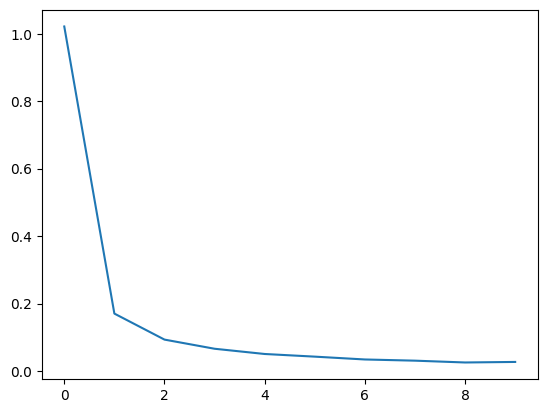

In [17]:
import matplotlib.pyplot as plt

plt.plot(history["train_loss"])